In [0]:
# Load Raw Data

from pyspark.sql import functions as F

df = spark.table('pense2024_bullying_psychological_distress.pense_2024_microdados')

df = df.select(
    'REGIAO', 'UF', 'CAPITAL', 'ANO_TURMA', 'DEP_ADMIN',
    'B01001A', 'IDADE_AGREG', 'B01002', 'B01021B',
    'B07007B', 'B07011A', 'B07012A',
    'B12004', 'B12005', 'B12006', 'B12007', 'B12008',
    'E01P117', 'B07004', 'B07006', 'B12003'
)

print(f'Linhas: {df.count():,} | Colunas: {len(df.columns)}')
df.show(3)

Linhas: 153,870 | Colunas: 21
+------+---+-------+---------+---------+-------+-----------+------+-------+-------+-------+-------+------+------+------+------+------+-------+------+------+------+
|REGIAO| UF|CAPITAL|ANO_TURMA|DEP_ADMIN|B01001A|IDADE_AGREG|B01002|B01021B|B07007B|B07011A|B07012A|B12004|B12005|B12006|B12007|B12008|E01P117|B07004|B07006|B12003|
+------+---+-------+---------+---------+-------+-----------+------+-------+-------+-------+-------+------+------+------+------+------+-------+------+------+------+
|     1| 11|      0|        2|        2|      2|          1|     4|      2|      1|      1|      1|     3|     3|     1|     4|     3|      1|     1|     4|     4|
|     1| 11|      0|        2|        2|      2|          2|     4|      2|      4|      1|      2|     4|     3|     3|     4|     3|      1|     5|     4|     4|
|     1| 11|      0|        2|        2|      1|          1|     4|      2|      1|      1|      1|     1|     2|     3|     2|     1|      4|     2| 

In [0]:
# Recode & Rename

# Missing values
missing_codes = [-9, -2, -1]
for col in df.columns:
    df = df.withColumn(
        col,
        F.when(F.col(col).isin(missing_codes), None).otherwise(F.col(col))
    )

# Recode moderators
df = df.withColumn(
    'E01P117',
    F.when(F.col('E01P117').isin([1, 2]), 1)
     .when(F.col('E01P117').isin([3, 4]), 0)
     .otherwise(None)
)

df = df.withColumn(
    'B07004',
    F.when(F.col('B07004') == 1,         0)
     .when(F.col('B07004').isin([2, 3]), 1)
     .when(F.col('B07004').isin([4, 5]), 2)
     .otherwise(None)
)

df = df.withColumn(
    'B07006',
    F.when(F.col('B07006') == 1,         0)
     .when(F.col('B07006').isin([2, 3]), 1)
     .when(F.col('B07006').isin([4, 5]), 2)
     .otherwise(None)
)

df = df.withColumn(
    'B12003',
    F.when(F.col('B12003') == 1,            0)
     .when(F.col('B12003').isin([2, 3, 4]), 1)
     .otherwise(None)
)

# Rename
rename_map = {
    'REGIAO':     'region',
    'UF':         'state',
    'CAPITAL':    'capital',
    'ANO_TURMA':  'school_year_grade',
    'DEP_ADMIN':  'school_type',
    'B01001A':    'sex',
    'IDADE_AGREG':'age_group',
    'B01002':     'race',
    'B01021B':    'school_grade',
    'B07007B':    'bully_verbal',
    'B07011A':    'bully_relational',
    'B07012A':    'bully_physical',
    'B12004':     'mh_worry',
    'B12005':     'mh_sadness',
    'B12006':     'mh_uncared',
    'B12007':     'mh_irritable',
    'B12008':     'mh_worthless',
    'E01P117':    'support',
    'B07004':     'parent_understanding',
    'B07006':     'peer_kindness',
    'B12003':     'n_friends'
}

for old, new in rename_map.items():
    df = df.withColumnRenamed(old, new)

print(f'Colunas: {df.columns}')

Colunas: ['region', 'state', 'capital', 'school_year_grade', 'school_type', 'sex', 'age_group', 'race', 'school_grade', 'bully_verbal', 'bully_relational', 'bully_physical', 'mh_worry', 'mh_sadness', 'mh_uncared', 'mh_irritable', 'mh_worthless', 'support', 'parent_understanding', 'peer_kindness', 'n_friends']


In [0]:
# Missing Data Summary

from pyspark.sql.functions import col, count, when

pct_missing = df.select([
    (count(when(col(c).isNull(), c)) / df.count() * 100).alias(c)
    for c in df.columns
])
pct_missing.show(vertical=True)

-RECORD 0----------------------------------
 region               | 0.0                
 state                | 0.0                
 capital              | 0.0                
 school_year_grade    | 3.3365828296614026 
 school_type          | 0.0                
 sex                  | 3.3365828296614026 
 age_group            | 3.4132709430038344 
 race                 | 3.8935465002924543 
 school_grade         | 3.3749268863326187 
 bully_verbal         | 3.8448040553714176 
 bully_relational     | 3.8753493208552676 
 bully_physical       | 3.860401637746149  
 mh_worry             | 3.89614609735491   
 mh_sadness           | 3.84350425684019   
 mh_uncared           | 3.901345291479821  
 mh_irritable         | 3.8928966010268407 
 mh_worthless         | 3.962435822447521  
 support              | 3.458763891596803  
 parent_understanding | 3.877299018652109  
 peer_kindness        | 3.79086241632547   
 n_friends            | 3.755117956716709  



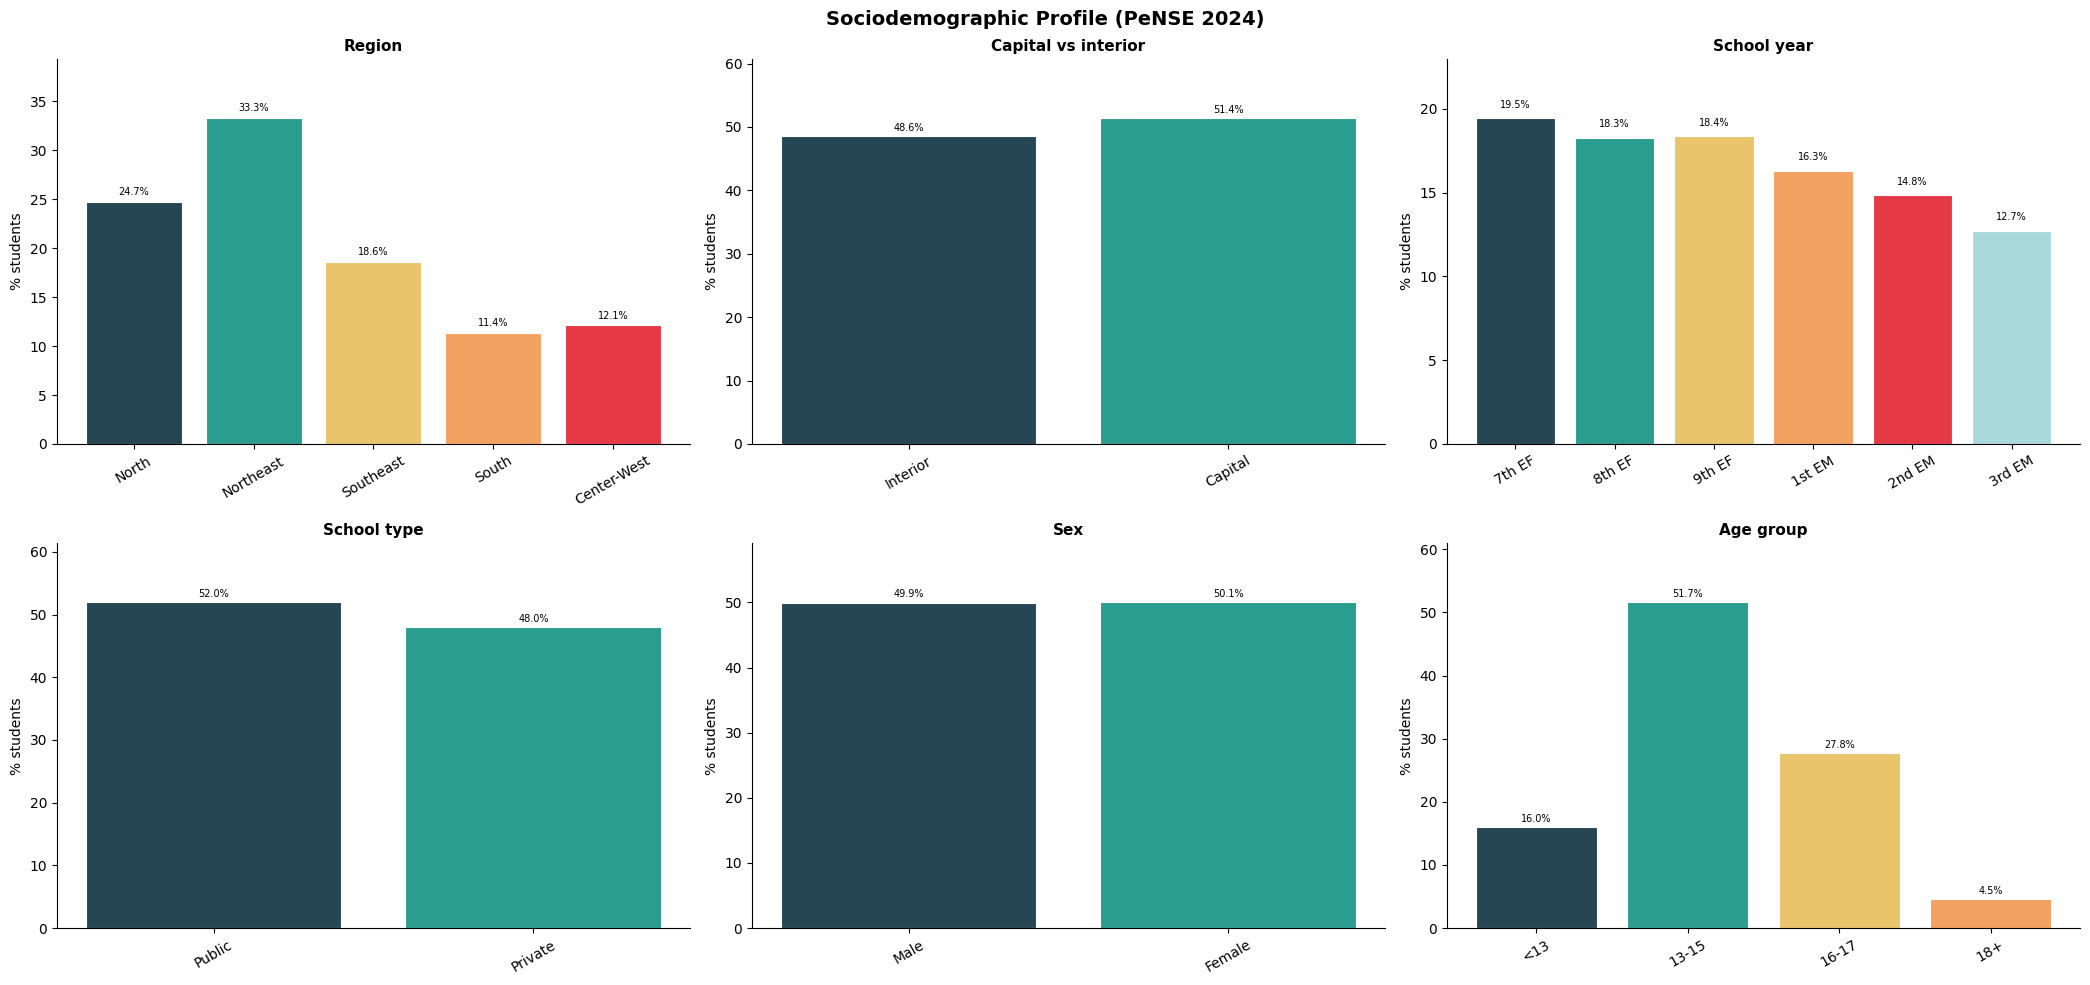

In [0]:
# Plots

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

dados = df.toPandas()

# Sociodemographic profile
fig, axes = plt.subplots(2, 3, figsize=(21, 10))
fig.suptitle('Sociodemographic Profile (PeNSE 2024)', fontsize=14, fontweight='bold')
axes = axes.flatten()

plots = [
    ('region',            'Region',             {1:'North', 2:'Northeast', 3:'Southeast', 4:'South', 5:'Center-West'}),
    ('capital',           'Capital vs interior', {0:'Interior', 1:'Capital'}),
    ('school_year_grade', 'School year',         {1:'7th EF', 2:'8th EF', 3:'9th EF', 4:'1st EM', 5:'2nd EM', 6:'3rd EM'}),
    ('school_type',       'School type',         {1:'Public', 2:'Private'}),
    ('sex',               'Sex',                 {1:'Male', 2:'Female'}),
    ('age_group',         'Age group',           {1:'<13', 2:'13-15', 3:'16-17', 4:'18+'}),
    ('race',              'Race',                {1:'White', 2:'Black', 3:'Asian', 4:'Brown', 5:'Indigenous'}),
]
colors = ['#264653','#2A9D8F','#E9C46A','#F4A261','#E63946','#A8DADC','#457B9D']

for ax, (var, title, label_map) in zip(axes, plots):
    sub    = dados[dados[var].notna()]
    counts = sub[var].value_counts(normalize=True).sort_index() * 100
    counts.index = [label_map.get(k, str(k)) for k in counts.index]
    bars = ax.bar(counts.index, counts.values,
                  color=colors[:len(counts)], edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=7)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('% students')
    ax.set_ylim(0, max(counts.values) * 1.18)
    ax.tick_params(axis='x', rotation=30)
    ax.spines[['top','right']].set_visible(False)

# Esconde o último subplot vazio (7 plots em grade 2x3 = 6 slots, ajusta para 2x4)
for ax in axes[len(plots):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

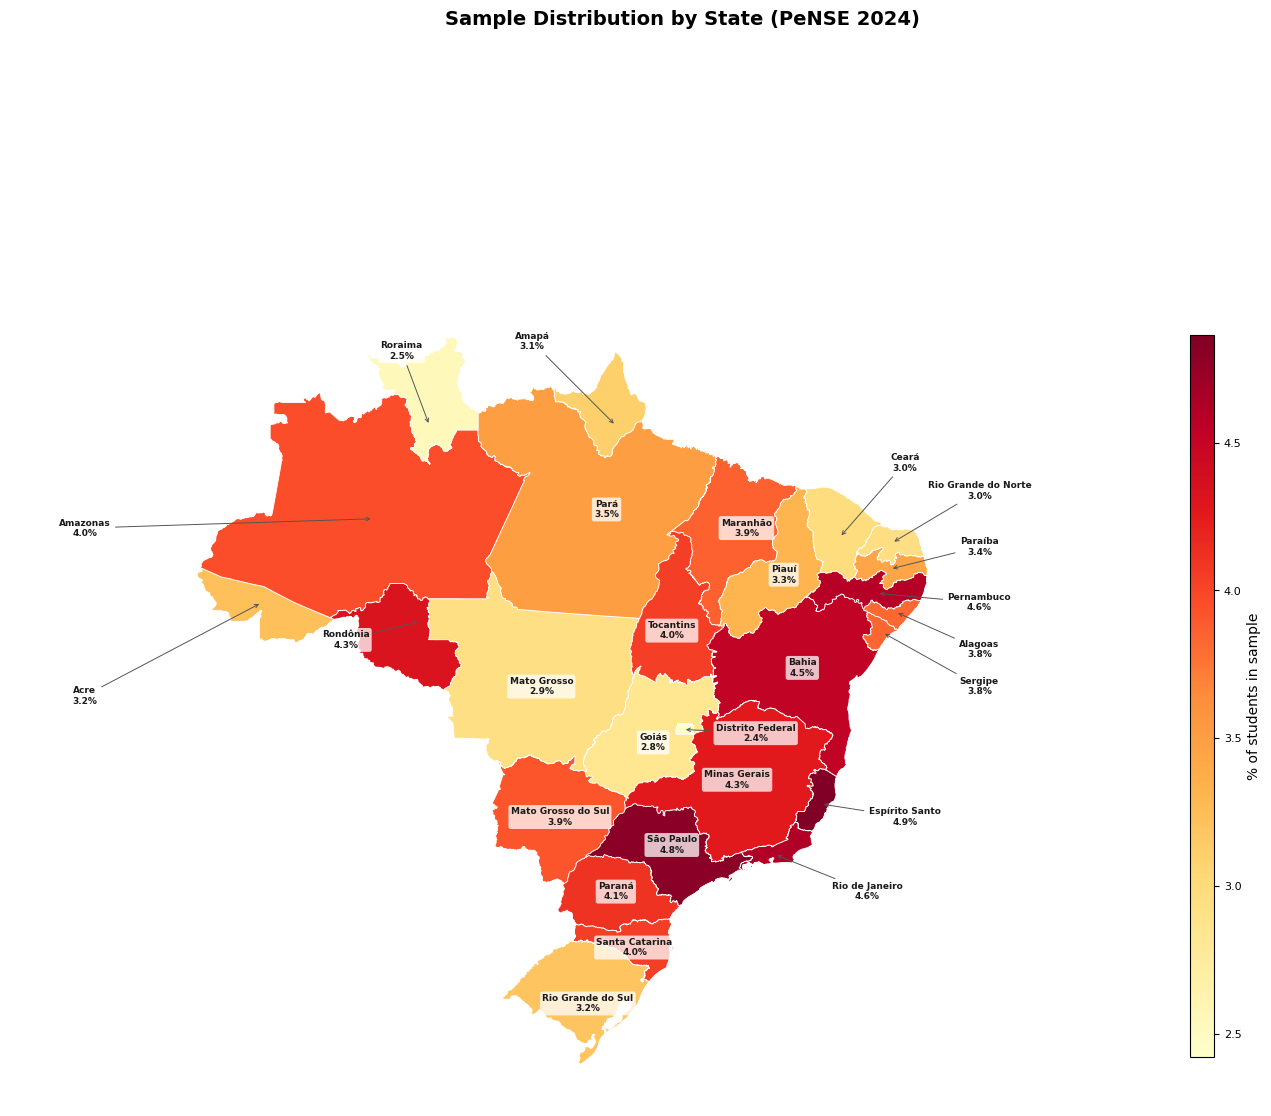

In [0]:
# Map

import json
import urllib.request
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

uf_map = {
    11:'RO', 12:'AC', 13:'AM', 14:'RR', 15:'PA', 16:'AP', 17:'TO',
    21:'MA', 22:'PI', 23:'CE', 24:'RN', 25:'PB', 26:'PE', 27:'AL',
    28:'SE', 29:'BA', 31:'MG', 32:'ES', 33:'RJ', 35:'SP',
    41:'PR', 42:'SC', 43:'RS', 50:'MS', 51:'MT', 52:'GO', 53:'DF'
}

uf_names = {
    'RO':'Rondônia',       'AC':'Acre',              'AM':'Amazonas',
    'RR':'Roraima',        'PA':'Pará',              'AP':'Amapá',
    'TO':'Tocantins',      'MA':'Maranhão',          'PI':'Piauí',
    'CE':'Ceará',          'RN':'Rio Grande do Norte','PB':'Paraíba',
    'PE':'Pernambuco',     'AL':'Alagoas',           'SE':'Sergipe',
    'BA':'Bahia',          'MG':'Minas Gerais',      'ES':'Espírito Santo',
    'RJ':'Rio de Janeiro', 'SP':'São Paulo',         'PR':'Paraná',
    'SC':'Santa Catarina', 'RS':'Rio Grande do Sul', 'MS':'Mato Grosso do Sul',
    'MT':'Mato Grosso',    'GO':'Goiás',             'DF':'Distrito Federal'
}

manual_pos = {
    'RO': (-62.0, -10.0), 'AC': (-70.5,  -9.0), 'AM': (-64.5,  -4.5),
    'RR': (-61.5,   0.5), 'PA': (-52.0,  -4.0), 'AP': (-51.5,   0.5),
    'TO': (-48.5, -10.5), 'MA': (-44.5,  -5.0), 'PI': (-42.5,  -7.5),
    'CE': (-39.5,  -5.5), 'RN': (-36.7,  -5.8), 'PB': (-36.8,  -7.2),
    'PE': (-37.5,  -8.5), 'AL': (-36.5,  -9.5), 'SE': (-37.2, -10.6),
    'BA': (-41.5, -12.5), 'MG': (-45.0, -18.5), 'ES': (-40.5, -19.8),
    'RJ': (-43.0, -22.5), 'SP': (-48.5, -22.0), 'PR': (-51.5, -24.5),
    'SC': (-50.5, -27.5), 'RS': (-53.0, -30.5), 'MS': (-54.5, -20.5),
    'MT': (-55.5, -13.5), 'GO': (-49.5, -16.5), 'DF': (-47.9, -15.8),
}

text_positions = {
    'RO': (-66.0, -11.0), 'AC': (-80.0, -14.0), 'AM': (-80.0,  -5.0),
    'RR': (-63.0,   4.5), 'PA': (-52.0,  -4.0), 'AP': (-56.0,   5.0),
    'TO': (-48.5, -10.5), 'MA': (-44.5,  -5.0), 'PI': (-42.5,  -7.5),
    'CE': (-36.0,  -1.5), 'RN': (-32.0,  -3.0), 'PB': (-32.0,  -6.0),
    'PE': (-32.0,  -9.0), 'AL': (-32.0, -11.5), 'SE': (-32.0, -13.5),
    'BA': (-41.5, -12.5), 'MG': (-45.0, -18.5), 'ES': (-36.0, -20.5),
    'RJ': (-38.0, -24.5), 'SP': (-48.5, -22.0), 'PR': (-51.5, -24.5),
    'SC': (-50.5, -27.5), 'RS': (-53.0, -30.5), 'MS': (-54.5, -20.5),
    'MT': (-55.5, -13.5), 'GO': (-49.5, -16.5), 'DF': (-44.0, -16.0),
}

uf_counts = dados['state'].value_counts(normalize=True).sort_index() * 100
uf_pct    = {uf_map[int(k)]: v for k, v in uf_counts.items() if int(k) in uf_map}

url = 'https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson'
with urllib.request.urlopen(url) as r:
    geojson = json.loads(r.read())

fig, ax = plt.subplots(figsize=(14, 14))
fig.suptitle('Sample Distribution by State (PeNSE 2024)',
             fontsize=14, fontweight='bold', y=0.97)

cmap = plt.cm.YlOrRd
norm = mcolors.Normalize(vmin=min(uf_pct.values()), vmax=max(uf_pct.values()))

for feature in geojson['features']:
    sigla = feature['properties']['sigla']
    pct   = uf_pct.get(sigla, 0)
    color = cmap(norm(pct))
    geom  = feature['geometry']

    if geom['type'] == 'Polygon':
        coords = [geom['coordinates'][0]]
    else:
        coords = [c[0] for c in geom['coordinates']]

    for ring in coords:
        xs = [p[0] for p in ring]
        ys = [p[1] for p in ring]
        ax.fill(xs, ys, color=color, edgecolor='white', linewidth=0.6)

for feature in geojson['features']:
    sigla = feature['properties']['sigla']
    pct   = uf_pct.get(sigla, 0)
    name  = uf_names.get(sigla, sigla)
    cx, cy = manual_pos.get(sigla, (0, 0))
    tx, ty = text_positions.get(sigla, (cx, cy))

    ax.annotate(
        f'{name}\n{pct:.1f}%',
        xy=(cx, cy),
        xytext=(tx, ty),
        fontsize=6.5, fontweight='bold', color='#1a1a1a',
        ha='center', va='center',
        arrowprops=dict(arrowstyle='->', color='#555555', lw=0.7),
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.75, edgecolor='none')
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.020, pad=0.02, aspect=30)
cbar.set_label('% of students in sample', fontsize=10)
cbar.ax.tick_params(labelsize=8)

ax.set_aspect('equal')
ax.set_axis_off()
ax.set_xlim(-84, -22)
ax.set_ylim(-36, 8)
plt.subplots_adjust(top=0.94, bottom=0.02, left=0.02, right=0.88)
plt.show()

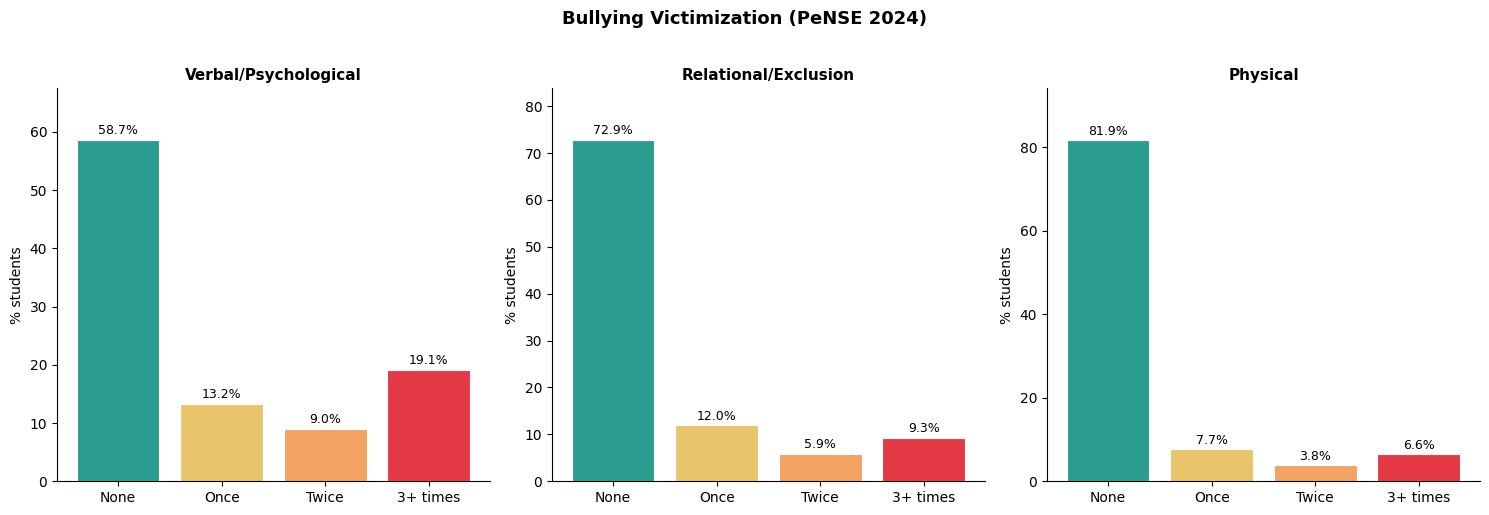

In [0]:
# Bullying

bully_vars = {
    'bully_verbal':     'Verbal/Psychological',
    'bully_relational': 'Relational/Exclusion',
    'bully_physical':   'Physical'
}
cat_bully = {1:'None', 2:'Once', 3:'Twice', 4:'3+ times'}
colors_b  = ['#2A9D8F','#E9C46A','#F4A261','#E63946']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Bullying Victimization (PeNSE 2024)', fontsize=13, fontweight='bold', y=1.02)

for i, (var, label) in enumerate(bully_vars.items()):
    sub    = dados[dados[var].notna()]
    counts = sub[var].value_counts(normalize=True).sort_index().reindex([1,2,3,4], fill_value=0) * 100
    bars   = axes[i].bar([cat_bully[k] for k in counts.index], counts.values,
                          color=colors_b, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
    axes[i].set_title(label, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('% students')
    axes[i].set_ylim(0, max(counts.values) * 1.15)
    axes[i].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

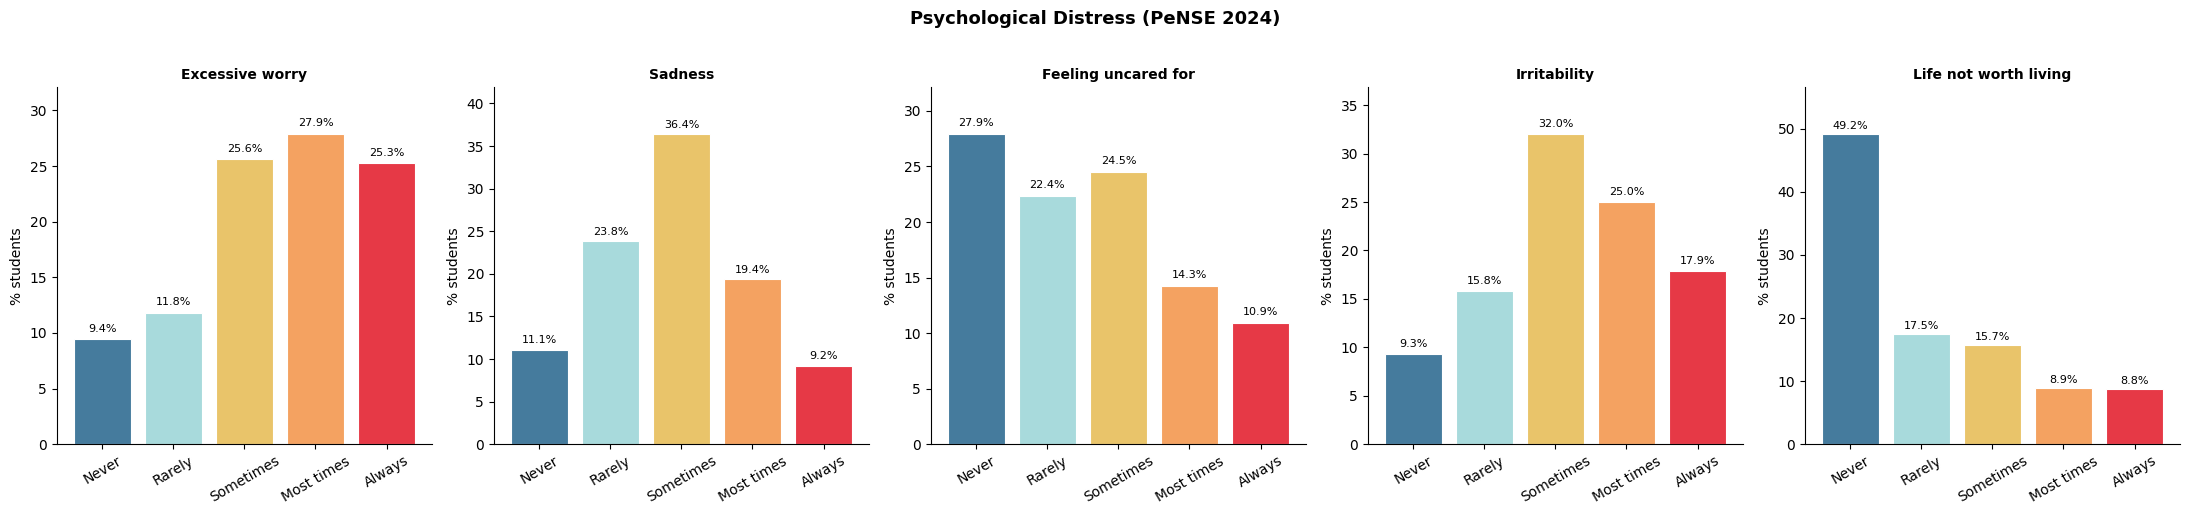

In [0]:
# Psychological distress

mh_vars  = {
    'mh_worry':     'Excessive worry',
    'mh_sadness':   'Sadness',
    'mh_uncared':   'Feeling uncared for',
    'mh_irritable': 'Irritability',
    'mh_worthless': 'Life not worth living'
}
cat_mh   = {1:'Never', 2:'Rarely', 3:'Sometimes', 4:'Most times', 5:'Always'}
colors_mh= ['#457B9D','#A8DADC','#E9C46A','#F4A261','#E63946']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle('Psychological Distress (PeNSE 2024)', fontsize=13, fontweight='bold', y=1.02)

for i, (var, label) in enumerate(mh_vars.items()):
    sub    = dados[dados[var].notna()]
    counts = sub[var].value_counts(normalize=True).sort_index().reindex([1,2,3,4,5], fill_value=0) * 100
    bars   = axes[i].bar([cat_mh[k] for k in counts.index], counts.values,
                          color=colors_mh, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=8)
    axes[i].set_title(label, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('% students')
    axes[i].set_ylim(0, max(counts.values) * 1.15)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

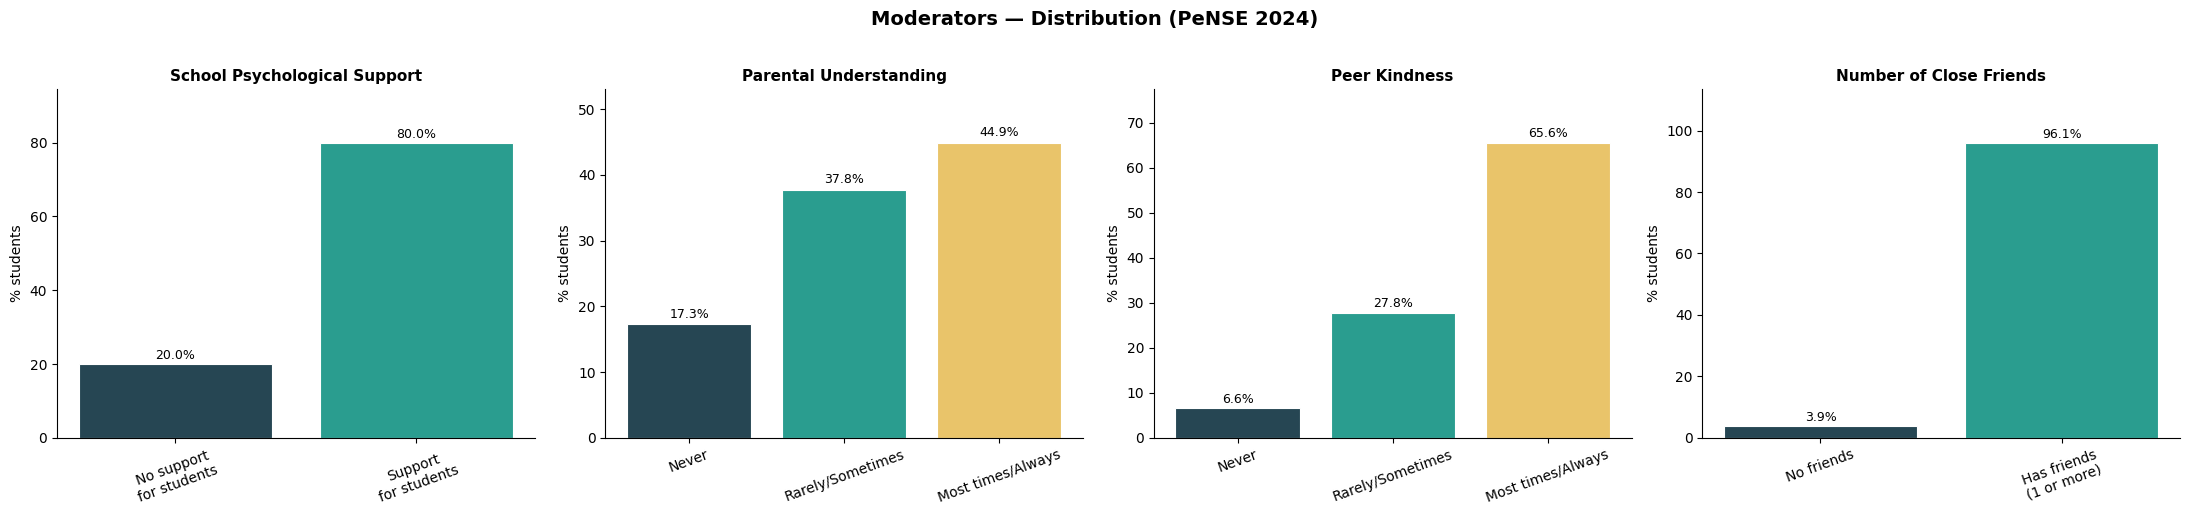

In [0]:
# Moderators

mod_vars = {
    'support': {
        'title': 'School Psychological Support',
        'labels': {0: 'No support\nfor students', 1: 'Support\nfor students'}
    },
    'parent_understanding': {
        'title': 'Parental Understanding',
        'labels': {0: 'Never', 1: 'Rarely/Sometimes', 2: 'Most times/Always'}
    },
    'peer_kindness': {
        'title': 'Peer Kindness',
        'labels': {0: 'Never', 1: 'Rarely/Sometimes', 2: 'Most times/Always'}
    },
    'n_friends': {
        'title': 'Number of Close Friends',
        'labels': {0: 'No friends', 1: 'Has friends\n(1 or more)'}
    },
}

colors_mod = ['#264653','#2A9D8F','#E9C46A','#F4A261','#E63946']

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Moderators — Distribution (PeNSE 2024)',
             fontsize=14, fontweight='bold', y=1.02)

for ax, (var, info) in zip(axes, mod_vars.items()):
    sub    = dados[dados[var].notna()]
    counts = sub[var].value_counts(normalize=True).sort_index() * 100
    counts.index = [info['labels'].get(k, str(k)) for k in counts.index]
    bars = ax.bar(counts.index, counts.values,
                  color=colors_mod[:len(counts)], edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
    ax.set_title(info['title'], fontsize=11, fontweight='bold')
    ax.set_ylabel('% students')
    ax.set_ylim(0, max(counts.values) * 1.18)
    ax.tick_params(axis='x', rotation=20)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

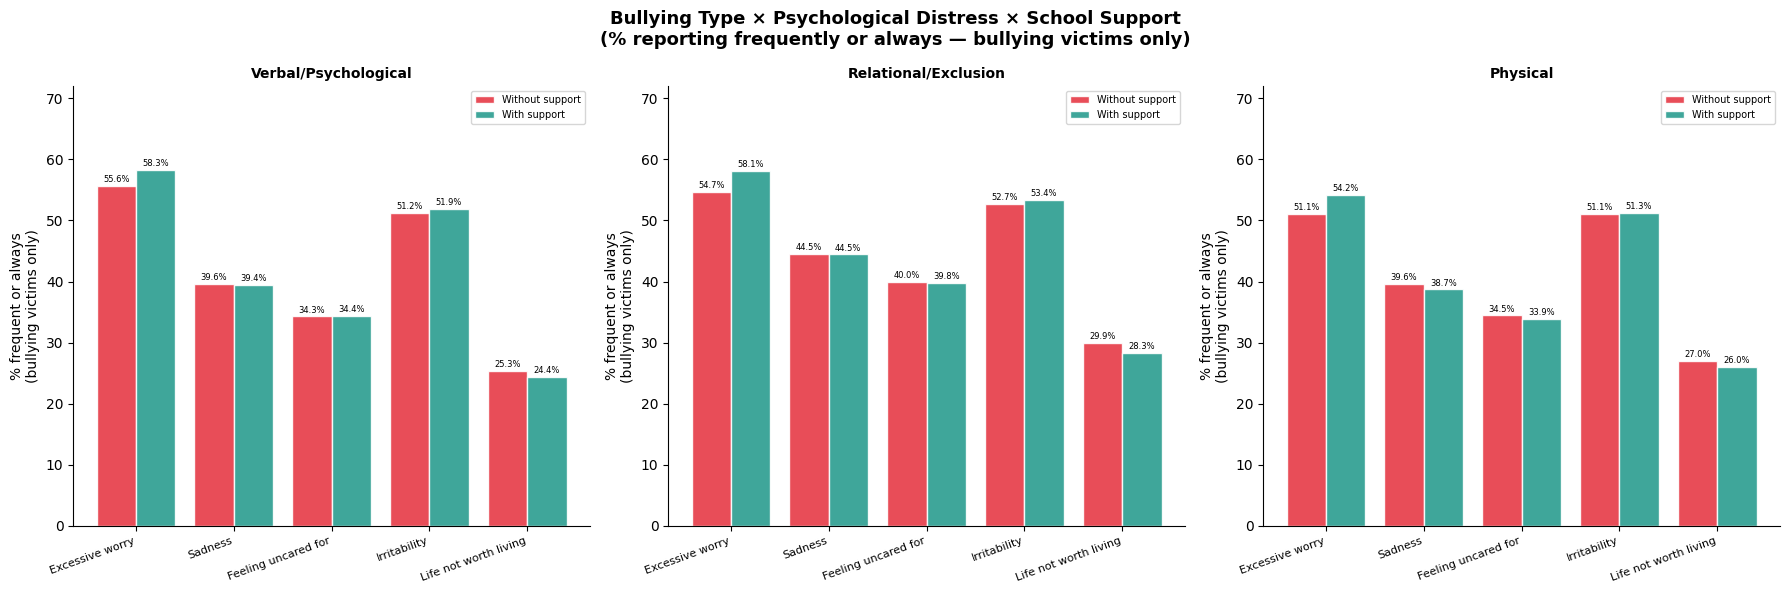

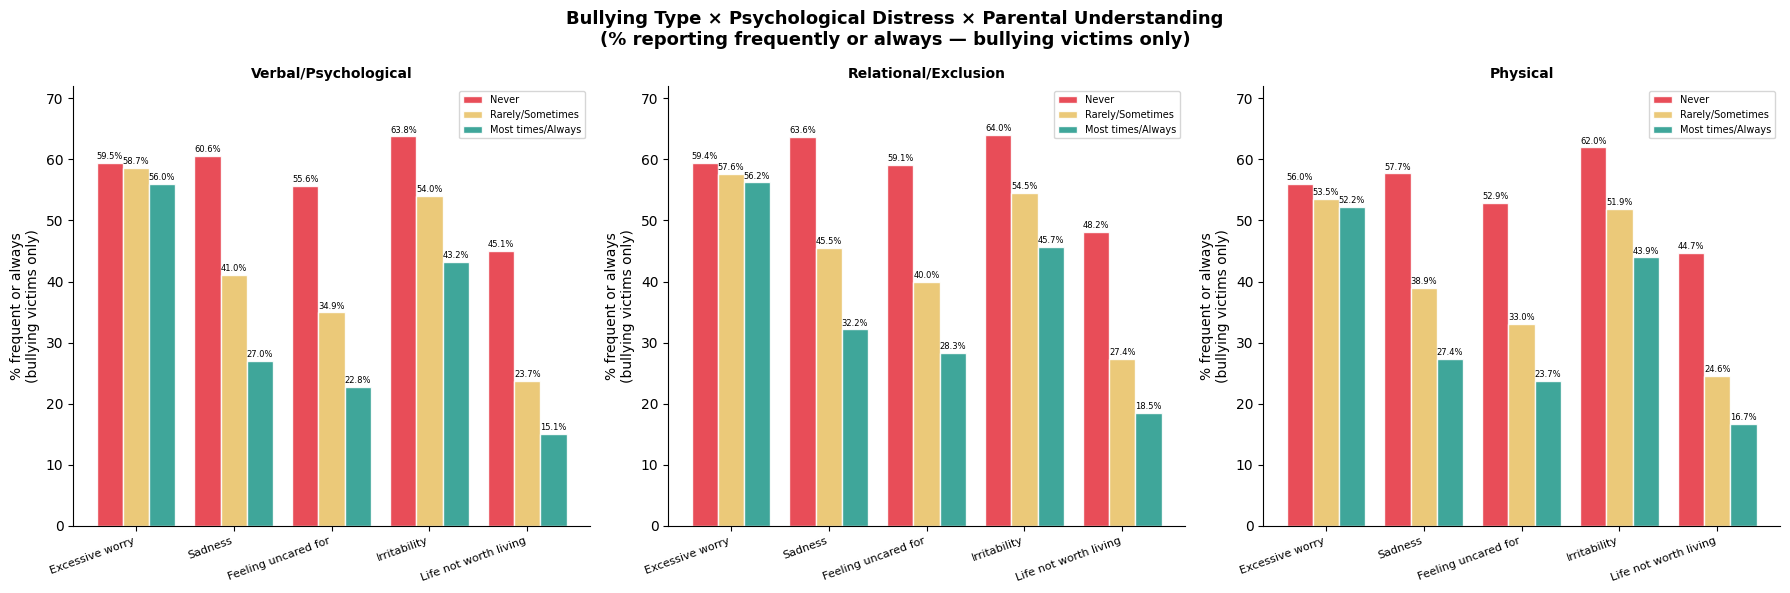

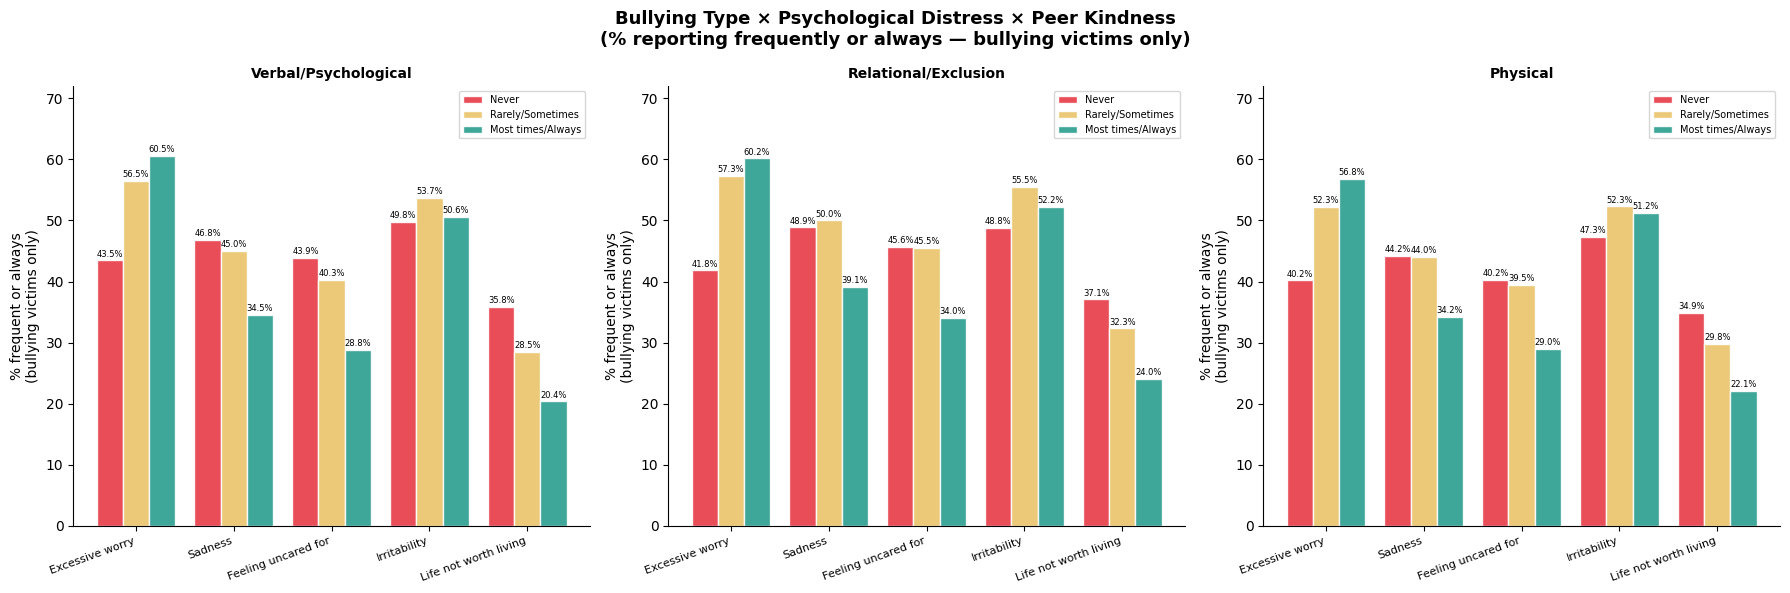

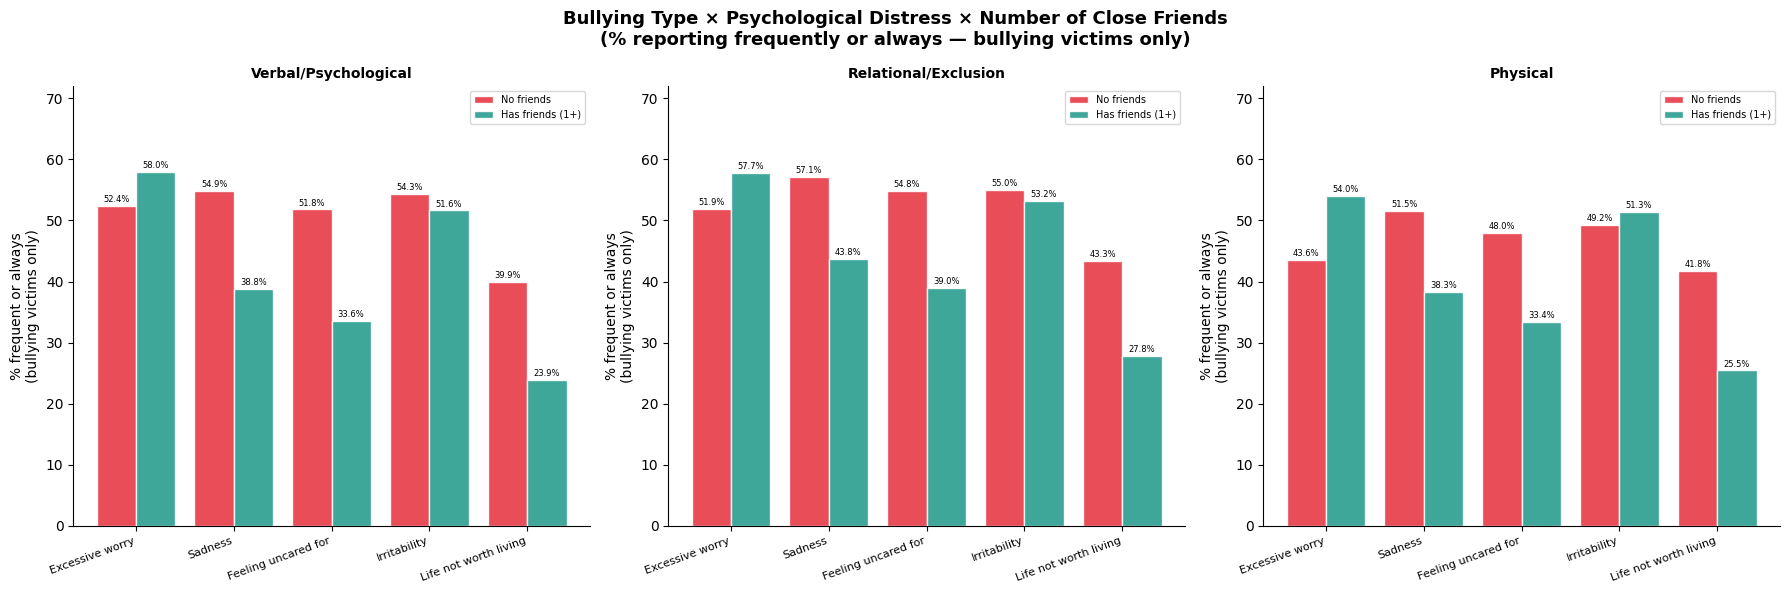

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

dados = df.toPandas()

mh_vars = {
    'mh_worry':     'Excessive worry',
    'mh_sadness':   'Sadness',
    'mh_uncared':   'Feeling uncared for',
    'mh_irritable': 'Irritability',
    'mh_worthless': 'Life not worth living'
}

bully_vars = {
    'bully_verbal':     'Verbal/Psychological',
    'bully_relational': 'Relational/Exclusion',
    'bully_physical':   'Physical'
}

# Labels atualizados com as novas recodificações
support_labels  = {0: 'Without support', 1: 'With support'}
parent_labels   = {0: 'Never', 1: 'Rarely/Sometimes', 2: 'Most times/Always'}
peer_labels     = {0: 'Never', 1: 'Rarely/Sometimes', 2: 'Most times/Always'}
friends_labels  = {0: 'No friends', 1: 'Has friends (1+)'}

dados['support_label']  = dados['support'].map(support_labels)
dados['parent_label']   = dados['parent_understanding'].map(parent_labels)
dados['peer_label']     = dados['peer_kindness'].map(peer_labels)
dados['friends_label']  = dados['n_friends'].map(friends_labels)

colors_2 = ['#E63946', '#2A9D8F']
colors_3 = ['#E63946', '#E9C46A', '#2A9D8F']

def bar_plot_mh(fig, axes, mh_vars, bully_vars, group_col, group_levels, colors, title):
    for i, (bully_var, bully_label) in enumerate(bully_vars.items()):
        ax  = axes[i]
        sub = dados[dados[bully_var].notna() & dados[group_col].notna()].copy()
        sub = sub[sub[bully_var] > 1]

        n     = len(group_levels)
        x     = np.arange(len(mh_vars))
        width = 0.8 / n

        for k, (grp, color) in enumerate(zip(group_levels, colors)):
            vals = []
            for mh_var in mh_vars.keys():
                s   = sub[sub[group_col] == grp][mh_var].dropna()
                pct = ((s >= 4).sum() / len(s) * 100) if len(s) > 0 else 0
                vals.append(pct)

            offset = (k - (n-1)/2) * width
            bars = ax.bar(x + offset, vals, width,
                          label=grp, color=color, edgecolor='white', alpha=0.9)
            for bar, val in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                        f'{val:.1f}%', ha='center', va='bottom', fontsize=6)

        ax.set_title(bully_label, fontsize=10, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(list(mh_vars.values()), fontsize=8, rotation=20, ha='right')
        ax.set_ylabel('% frequent or always\n(bullying victims only)')
        ax.set_ylim(0, 72)
        ax.legend(fontsize=7)
        ax.spines[['top','right']].set_visible(False)

    fig.suptitle(title, fontsize=13, fontweight='bold')

# Moderator 1: School support
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
bar_plot_mh(fig, axes, mh_vars, bully_vars,
    group_col    = 'support_label',
    group_levels = ['Without support', 'With support'],
    colors       = colors_2,
    title        = 'Bullying Type × Psychological Distress × School Support\n(% reporting frequently or always — bullying victims only)')
plt.tight_layout()
plt.show()

# Moderator 2: Parental understanding
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
bar_plot_mh(fig, axes, mh_vars, bully_vars,
    group_col    = 'parent_label',
    group_levels = ['Never', 'Rarely/Sometimes', 'Most times/Always'],
    colors       = colors_3,
    title        = 'Bullying Type × Psychological Distress × Parental Understanding\n(% reporting frequently or always — bullying victims only)')
plt.tight_layout()
plt.show()

# Moderator 3: Peer kindness
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
bar_plot_mh(fig, axes, mh_vars, bully_vars,
    group_col    = 'peer_label',
    group_levels = ['Never', 'Rarely/Sometimes', 'Most times/Always'],
    colors       = colors_3,
    title        = 'Bullying Type × Psychological Distress × Peer Kindness\n(% reporting frequently or always — bullying victims only)')
plt.tight_layout()
plt.show()

# Moderator 4: Number of close friends
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
bar_plot_mh(fig, axes, mh_vars, bully_vars,
    group_col    = 'friends_label',
    group_levels = ['No friends', 'Has friends (1+)'],
    colors       = colors_2,
    title        = 'Bullying Type × Psychological Distress × Number of Close Friends\n(% reporting frequently or always — bullying victims only)')
plt.tight_layout()
plt.show()

In [0]:
# Save Delta Table

export_cols = [
    'region', 'state', 'capital', 'school_year_grade', 'school_type',
    'sex', 'age_group', 'race', 'school_grade',
    'bully_verbal', 'bully_relational', 'bully_physical',
    'mh_worry', 'mh_sadness', 'mh_uncared', 'mh_irritable', 'mh_worthless',
    'support', 'parent_understanding', 'peer_kindness', 'n_friends'
]

df_spark = spark.createDataFrame(dados[export_cols])

(df_spark.write
    .format('delta')
    .mode('overwrite')
    .option('overwriteSchema', 'true')
    .saveAsTable('pense2024_bullying_psychological_distress.pense_2024_clean'))

print('✅  Table pense_2024_clean saved successfully.')
print(f'    Rows: {df_spark.count():,} | Columns: {len(df_spark.columns)}')

✅  Table pense_2024_clean saved successfully.
    Rows: 153,870 | Columns: 21


In [0]:
dados.head(15)

,region,state,capital,school_year_grade,school_type,sex,age_group,race,school_grade,bully_verbal,bully_relational,bully_physical,mh_worry,mh_sadness,mh_uncared,mh_irritable,mh_worthless,support,parent_understanding,peer_kindness,n_friends,support_label,parent_label,peer_label,friends_label
0,1,11,0,2.0,2,2.0,1.0,4.0,2.0,1.0,1.0,1.0,3.0,3.0,1.0,4.0,3.0,1.0,0.0,2.0,1.0,With support,Never,Most times/Always,Has friends (1+)
1,1,11,0,2.0,2,2.0,2.0,4.0,2.0,4.0,1.0,2.0,4.0,3.0,3.0,4.0,3.0,1.0,2.0,2.0,1.0,With support,Most times/Always,Most times/Always,Has friends (1+)
2,1,11,0,2.0,2,1.0,1.0,4.0,2.0,1.0,1.0,1.0,1.0,2.0,3.0,2.0,1.0,0.0,1.0,2.0,1.0,Without support,Rarely/Sometimes,Most times/Always,Has friends (1+)
3,1,11,0,2.0,2,1.0,2.0,4.0,2.0,4.0,1.0,1.0,4.0,5.0,4.0,5.0,4.0,1.0,2.0,1.0,1.0,With support,Most times/Always,Rarely/Sometimes,Has friends (1+)
4,1,11,0,2.0,2,1.0,1.0,4.0,2.0,1.0,2.0,1.0,1.0,2.0,1.0,2.0,2.0,0.0,2.0,1.0,1.0,Without support,Most times/Always,Rarely/Sometimes,Has friends (1+)
5,1,11,0,2.0,2,2.0,1.0,4.0,2.0,1.0,3.0,1.0,3.0,2.0,2.0,4.0,1.0,1.0,2.0,1.0,1.0,With support,Most times/Always,Rarely/Sometimes,Has friends (1+)
6,1,11,0,2.0,2,2.0,1.0,4.0,2.0,4.0,3.0,2.0,4.0,4.0,4.0,3.0,4.0,0.0,0.0,1.0,1.0,Without support,Never,Rarely/Sometimes,Has friends (1+)
7,1,11,0,2.0,2,1.0,2.0,4.0,2.0,1.0,4.0,1.0,3.0,4.0,4.0,2.0,4.0,1.0,0.0,0.0,1.0,With support,Never,Never,Has friends (1+)
8,1,11,0,2.0,2,2.0,2.0,1.0,2.0,3.0,4.0,1.0,3.0,5.0,5.0,5.0,5.0,1.0,1.0,2.0,1.0,With support,Rarely/Sometimes,Most times/Always,Has friends (1+)
9,1,11,0,2.0,2,1.0,2.0,4.0,2.0,1.0,1.0,1.0,1.0,4.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,With support,Never,Never,Has friends (1+)
